<a href="https://colab.research.google.com/github/kwanda2426/Data_Visualisation_Exploration_A1/blob/main/assignment1_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMS7056A — Assignment 1
**Dataset:** `logbook_assignment1.csv` — vehicle fuel logbook scraped from user submissions

In [1]:
%pip -q install --upgrade pip
!pip -q install plotly scikit-learn tabulate pandas gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.6 MB/s eta 0:00:00


In [2]:
# Libraries for data loading, data manipulation and data visualisation
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import gdown

import random
from pathlib import Path

plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', '{:,.4f}'.format)

#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate
from IPython.display import display

In [3]:
# Reading and downloading from drive
file_id = "1klHxC56j2ja9QtGNveHEUo5MixwRB0x-"
url = f"https://drive.google.com/uc?id={file_id}"

output = "data.csv"
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1klHxC56j2ja9QtGNveHEUo5MixwRB0x-
From (redirected): https://drive.google.com/uc?id=1klHxC56j2ja9QtGNveHEUo5MixwRB0x-&confirm=t&uuid=adc38f80-b656-41a0-aa2f-80b3d1dc7a4d
To: /content/data.csv
100%|██████████| 135M/135M [00:00<00:00, 172MB/s]


'data.csv'

In [4]:
# Read data and check the memory usage of the dataframe
df_1 = pd.read_csv(output, dtype = str, low_memory = False)
print(f'Shape: {df_1.shape}')
print(f'Memory (strings): {df_1.memory_usage(deep = True).sum() / 1e6:.1f} MB')
df_1.head(3)

Shape: (1174870, 9)
Memory (strings): 621.0 MB


,date_fueled,date_captured,odometer,gallons,cost_per_gallon,total_spent,mpg,miles,user_url
0,"Cooling System, Heating System, Lights, Spark Plugs",Apr 7 2022,"73,370",NaN,NaN,NaN,NaN,NaN,https://www.somewebsite.com/suzuki/swift/2015/674857
1,Nov 7 2012,Aug 30 2016,"11,983",12.120,$5.599,$67.86,31.6,NaN,https://www.somewebsite.com/bmw/x3/2009/461150
2,Sep 22 2012,Sep 28 2012,"98,233",7.991,£5.45,£43.53,28.5,NaN,https://www.somewebsite.com/mercedes-benz/e300/1998/133501


In [5]:
# dataframe
df = df_1.copy()

---
## Section 1.1 — Date Fields

In [6]:
# Q1.1.1 — What percentage of date_fueled entries are not proper dates?
date_fueled_parsed = pd.to_datetime(df['date_fueled'], errors='coerce').dt.date

n_invalid = date_fueled_parsed.isna().sum()
pct_invalid = n_invalid/len(df)*100

print(f'Total rows          : {len(df)}')
print(f'Invalid date_fueled : {n_invalid}  ({pct_invalid:.2f}%)')

Total rows          : 1174870
Invalid date_fueled : 136962  (11.66%)


In [7]:
# Q1.1.2 — Fill invalid date_fueled with date_captured when date_captured is a valid date
date_captured_parsed = pd.to_datetime(df['date_captured'], errors='coerce').dt.date

date_fueled_filled = date_fueled_parsed.fillna(date_captured_parsed)

filled_count = date_fueled_filled.notna().sum() - date_fueled_parsed.notna().sum()
print(f'Entries filled from date_captured: {filled_count}')
print(f'Still missing after fill          : {date_fueled_filled.isna().sum()}')

Entries filled from date_captured: 136962
Still missing after fill          : 0


In [8]:
# Q1.1.3 — Assign cleaned dates back; anything still invalid becomes NaT
df['date_fueled']   = date_fueled_filled
df['date_captured'] = date_captured_parsed

print(f'NaT in date_fueled  : {df["date_fueled"].isna().sum()}')
print(f'NaT in date_captured: {df["date_captured"].isna().sum()}')
df[['date_fueled', 'date_captured']].dtypes

NaT in date_fueled  : 0
NaT in date_captured: 0


,0
date_fueled,object
date_captured,object


-- Future dates are based on date captured. Any fuel date beyond the date captured then gets removed.

-- Dates earlier than 2005 are removed.

In [9]:
print(df.date_captured.min())
print(df.date_captured.max())

2008-08-07
2022-04-16


In [10]:
# Q1.1.4 — Remove future dates.

df_2 = df.copy()
earlier_date = pd.to_datetime('2005-01-01').date()
future_dte = df.date_captured.max()
n_before = len(df)

valid_range = (
    (df['date_fueled'] >= earlier_date) &
    (df['date_fueled'] <= future_dte)
)
df_final = df[valid_range].copy()

print(f'Rows removed : {n_before - len(df_final)}')
print(f'Rows kept    : {len(df_final)}')
print('')
#checks
print('minimum and maximum fuel date')
print(df_final.date_fueled.min())
print(df_final.date_fueled.max())

Rows removed : 780
Rows kept    : 1174090

minimum and maximum fuel date
2005-01-02
2022-04-16


In [11]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1174090 entries, 0 to 1174869
Data columns (total 9 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   date_fueled      1174090 non-null  object
 1   date_captured    1174090 non-null  object
 2   odometer         1025179 non-null  object
 3   gallons          1099928 non-null  object
 4   cost_per_gallon  1093387 non-null  object
 5   total_spent      1099928 non-null  object
 6   mpg              1099928 non-null  object
 7   miles            146031 non-null   object
 8   user_url         1174090 non-null  object
dtypes: object(9)
memory usage: 89.6+ MB


In [12]:
# Q1.1.5 — Distribution of fueling dates
df_final['date_fueled'] = pd.to_datetime(
    df_final['date_fueled'],
    errors='coerce'
)

monthly = (
    df_final['date_fueled']
    .dt.to_period('M')
    .value_counts()
    .sort_index()
)

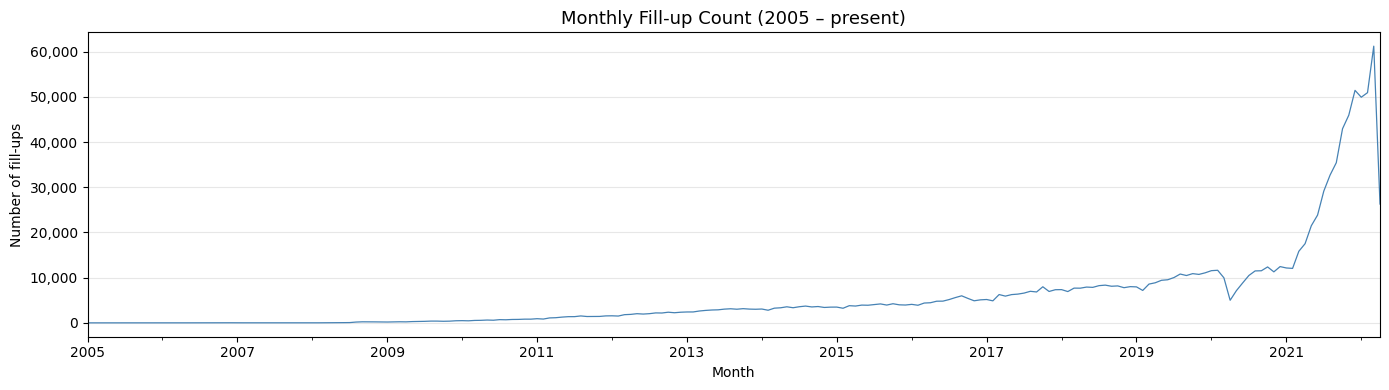

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))

monthly.plot(
    ax=ax,
    color='steelblue',
    linewidth=0.9
)

ax.set_title('Monthly Fill-up Count (2005 – present)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Number of fill-ups')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    'fig_1_1_5_date_distribution.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()



---
## Section 1.2 — Numeric Fields

> **Note:** Q1.2.3 (type conversion) is implemented first because Q1.2.1 (missing-value counts) and Q1.2.2 (interdependency fill) both require numeric columns.

In [14]:
# Q1.2.3 — Convert string columns to float
# Strip thousands commas and whitespace, then cast; unparseable values → NaN
df = df_final.copy()
for col in ['odometer', 'gallons', 'miles', 'mpg']:
    df[col] = (
        df[col]
        .str.replace(',', '', regex=False)
        .str.strip()
        .pipe(pd.to_numeric, errors='coerce')
    )

print('Dtypes after conversion:')
print(df[['odometer', 'gallons', 'miles', 'mpg']].dtypes)
print(f'\nMemory after numeric conversion: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Dtypes after conversion:
odometer    float64
gallons     float64
miles       float64
mpg         float64
dtype: object

Memory after numeric conversion: 356.1 MB


In [15]:
# Q1.2.1 — % missing for gallons, miles, odometer (post-conversion)
print('Missing values after string-to-float conversion:')
for col in ['gallons', 'miles', 'odometer']:
    n = df[col].isna().sum()
    print(f'  {col:10s}: {n}  ({n / len(df) * 100:.2f}%)')

Missing values after string-to-float conversion:
  gallons   : 74162  (6.32%)
  miles     : 1028059  (87.56%)
  odometer  : 148911  (12.68%)


In [16]:
# Q1.2.2 — Fill missing values using mpg = miles / gallons

# miles missing, but gallons and mpg known → miles = gallons * mpg
m = df['miles'].isna() & df['gallons'].notna() & df['mpg'].notna()
df.loc[m, 'miles'] = df.loc[m, 'gallons'] * df.loc[m, 'mpg']
print(f'miles  filled: {m.sum()}')

# gallons missing, but miles and mpg known → gallons = miles / mpg
m = df['gallons'].isna() & df['miles'].notna() & df['mpg'].notna()
df.loc[m, 'gallons'] = df.loc[m, 'miles'] / df.loc[m, 'mpg']
print(f'gallons filled: {m.sum()}')

# mpg missing, but miles and gallons known → mpg = miles / gallons
m = df['mpg'].isna() & df['miles'].notna() & df['gallons'].notna()
df.loc[m, 'mpg'] = df.loc[m, 'miles'] / df.loc[m, 'gallons']
print(f'mpg    filled: {m.sum()}')

print('\nMissing after interdependency fill:')
for col in ['gallons', 'miles', 'odometer', 'mpg']:
    n = df[col].isna().sum()
    print(f'  {col:10s}: {n}  ({n / len(df) * 100:.2f}%)')

miles  filled: 953897
gallons filled: 0
mpg    filled: 0

Missing after interdependency fill:
  gallons   : 74162  (6.32%)
  miles     : 74162  (6.32%)
  odometer  : 148911  (12.68%)
  mpg       : 74162  (6.32%)


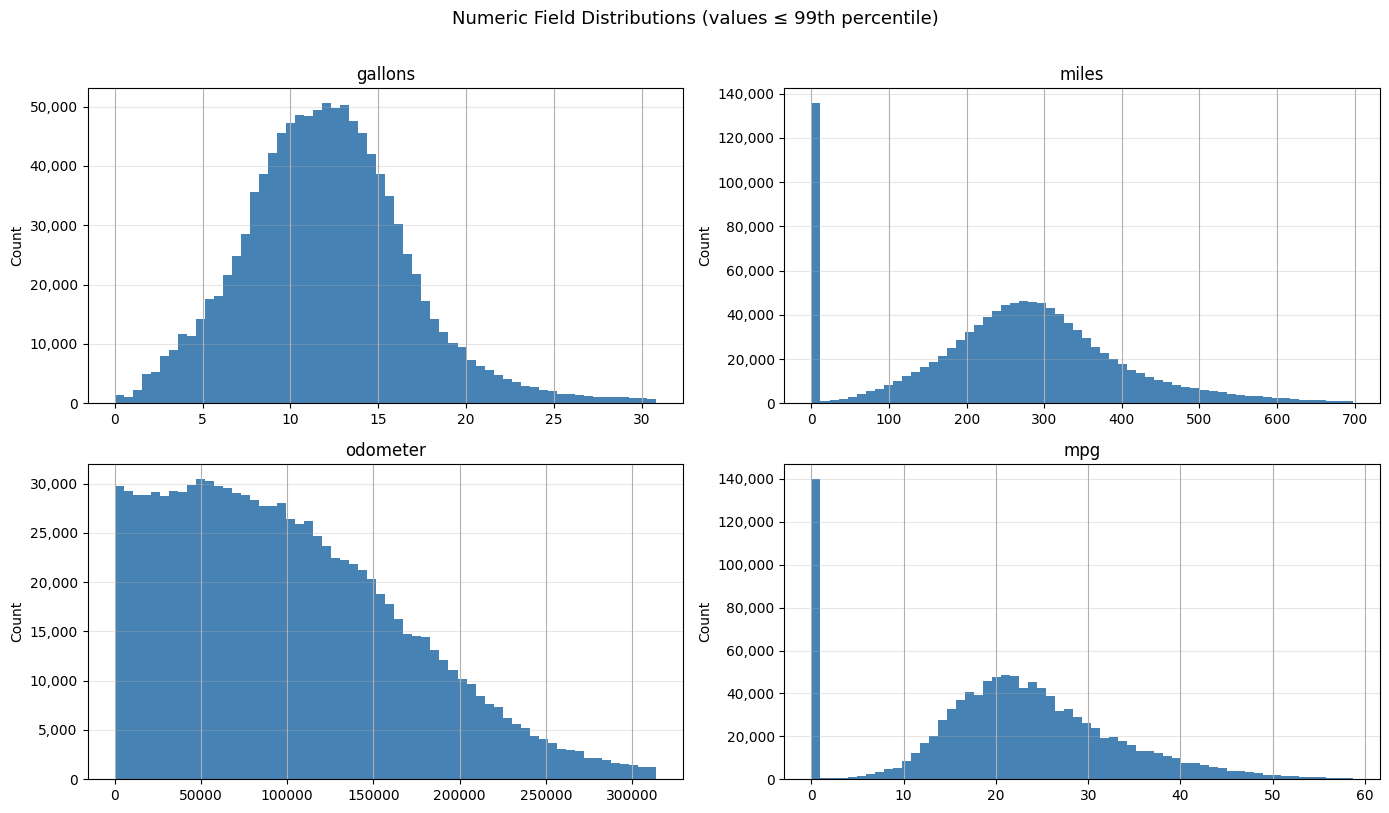

In [17]:
# Q1.2.4 — Distribution plots (capped at 99th percentile to suppress extreme outliers)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flat, ['gallons', 'miles', 'odometer', 'mpg']):
    data = df[col].dropna()
    cap = data.quantile(0.99)
    data[data <= cap].hist(bins=60, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(col, fontsize=12)
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Numeric Field Distributions (values \u2264 99th percentile)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_1_2_4_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Q1.2.5 — Statistical description: mean, std, min, max, quartiles, mode
cols = ['gallons', 'miles', 'odometer', 'mpg']

stats = df[cols].describe(percentiles=[0.25, 0.5, 0.75])

mode_row = pd.Series(
    {c: round(df[c].mode().iloc[0], 4) if not df[c].mode().empty else np.nan for c in cols},
    name = 'mode'
)

pd.concat([stats, mode_row.to_frame().T])

,gallons,miles,odometer,mpg
count,"1,099,928.0000","1,099,928.0000","1,025,179.0000","1,099,928.0000"
mean,12.7975,269.4479,"104,001.6803",22.1627
std,74.4896,725.8278,"340,610.9617",15.7452
min,0.0000,0.0000,0.0000,0.0000
25%,8.9900,181.3899,"45,926.0000",15.6000
50%,11.9540,267.0426,"91,888.0000",21.8000
75%,14.9390,342.7586,"146,926.0000",28.5000
max,"28,380.0000","195,321.2000","254,362,100.0000","1,214.3000"
mode,10.5670,0.0000,1.0000,0.0000


---
## Section 2 — Feature Engineering

In [19]:
# Q2.1 — Extract currency symbol from cost_per_gallon (fall back to total_spent)
# Swiss Franc symbol is 'Fr.' — regex captures any leading non-digit characters
currency_from_cpg = df['cost_per_gallon'].str.extract(r'^([^0-9\s]+)', expand=False)
currency_from_ts  = df['total_spent'].str.extract(r'^([^0-9\s]+)', expand=False)

df['currency'] = currency_from_cpg.fillna(currency_from_ts)

print('Top 15 currencies by count:')
print(df['currency'].value_counts().head(15))
print(f'\nRows with no currency: {df["currency"].isna().sum():,}')

Top 15 currencies by count:
currency
$      741876
£       87562
€       59258
CA$     46824
R       36396
AU$     23323
RM       8627
NZ$      7702
R$       6379
zł       5302
Skr      4994
Rs       4743
₱        4189
฿        4133
Dkr      3855
Name: count, dtype: int64

Rows with no currency: 74,162


In [20]:
# Q2.2 — Float values of cost_per_gallon and total_spent
# Strip the currency prefix (all leading non-digit chars), then strip commas and convert
df['cost_per_gallon_val'] = (
    df['cost_per_gallon']
    .str.replace(r'^[^0-9]+', '', regex=True)
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

df['total_spent_val'] = (
    df['total_spent']
    .str.replace(r'^[^0-9]+', '', regex=True)
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

print('cost_per_gallon_val — sample stats:')
print(df['cost_per_gallon_val'].describe())
print('\ntotal_spent_val — sample stats:')
print(df['total_spent_val'].describe())

cost_per_gallon_val — sample stats:
count   1,093,387.0000
mean          108.0184
std         1,680.4401
min             0.0000
25%             2.9990
50%             3.8690
75%             5.3300
max       189,270.5900
Name: cost_per_gallon_val, dtype: float64

total_spent_val — sample stats:
count     1,099,928.0000
mean          2,745.8485
std       1,182,911.8763
min               0.0000
25%              32.5100
50%              47.0600
75%              70.9800
max     899,647,469.0000
Name: total_spent_val, dtype: float64


In [21]:
# Q2.3 — Extract make, model, year, and user_id from user_url
# URL format: https://www.somewebsite.com/{make}/{model}/{year}/{user_id}
url_parts = df['user_url'].str.rstrip('/').str.split('/')

df['user_id'] = url_parts.str[-1]
df['year']    = pd.to_numeric(url_parts.str[-2], errors='coerce').astype('Int32')
df['model']   = url_parts.str[-3]
df['make']    = url_parts.str[-4]

print('Extracted columns sample:')
df[['user_url', 'make', 'model', 'year', 'user_id']].head(5)

Extracted columns sample:


,user_url,make,model,year,user_id
0,https://www.somewebsite.com/suzuki/swift/2015/674857,suzuki,swift,2015,674857
1,https://www.somewebsite.com/bmw/x3/2009/461150,bmw,x3,2009,461150
2,https://www.somewebsite.com/mercedes-benz/e300/1998/133501,mercedes-benz,e300,1998,133501
3,https://www.somewebsite.com/bmw/320d/2010/247233,bmw,320d,2010,247233
4,https://www.somewebsite.com/honda/passport/2019/1038865,honda,passport,2019,1038865


In [22]:
print('Year range:')
print(df['year'].describe())

# Unique makes and models
print(f'\nUnique makes : {df["make"].nunique():,}')
print(f'Unique models: {df["model"].nunique():,}')

Year range:
count   1,170,353.0000
mean        2,007.6637
std            17.7211
min           206.0000
25%         2,003.0000
50%         2,009.0000
75%         2,015.0000
max         2,022.0000
Name: year, dtype: Float64

Unique makes : 29
Unique models: 2,215


In [23]:
# Q2.4 — litres_filled
# UK users (currency = £) use Imperial (UK) gallons; everyone else uses US gallons.
# 1 UK gallon = 4.54609 litres  |  1 US gallon = 3.78541 litres
UK_GAL_TO_L = 4.54609
US_GAL_TO_L = 3.78541

df['litres_filled'] = np.where(
    df['currency'] == '\u00a3',          # £
    df['gallons'] * UK_GAL_TO_L,
    df['gallons'] * US_GAL_TO_L
)

print('litres_filled — stats:')
print(df['litres_filled'].describe())

litres_filled — stats:
count   1,099,928.0000
mean           49.1355
std           282.0192
min             0.0000
25%            34.5192
50%            45.8262
75%            57.4171
max       107,429.9358
Name: litres_filled, dtype: float64


In [24]:
# Q2.5 — km_driven
# 1 mile = 1.60934 km
df['km_driven'] = df['miles'] * 1.60934

print('km_driven — stats:')
print(df['km_driven'].describe())

km_driven — stats:
count   1,099,928.0000
mean          433.6333
std         1,168.1037
min             0.0000
25%           291.9180
50%           429.7623
75%           551.6151
max       314,338.2200
Name: km_driven, dtype: float64


In [25]:
# Q2.6 — litres per 100 km
df['litres_per_100km'] = (df['litres_filled'] / df['km_driven']) * 100

df['litres_per_100km'] = df['litres_per_100km'].replace([np.inf, -np.inf], np.nan)

print('litres_per_100km — stats (pre-outlier-removal):')
print(df['litres_per_100km'].describe())

# Peek at the sensible range (roughly 3–25 L/100km covers most real vehicles)
sensible = df['litres_per_100km'].between(3, 25)
print(f'\nRows in sensible range (3–25 L/100km): {sensible.sum()}  '
      f'({sensible.sum() / df["litres_per_100km"].notna().sum() * 100:.1f}%)')

litres_per_100km — stats (pre-outlier-removal):
count   965,184.0000
mean         12.3207
std          48.5542
min           0.0000
25%           8.0553
50%          10.2267
75%          13.0675
max      12,426.4115
Name: litres_per_100km, dtype: float64

Rows in sensible range (3–25 L/100km): 939190  (97.3%)


---
## Section 3 — Vehicle Exploration

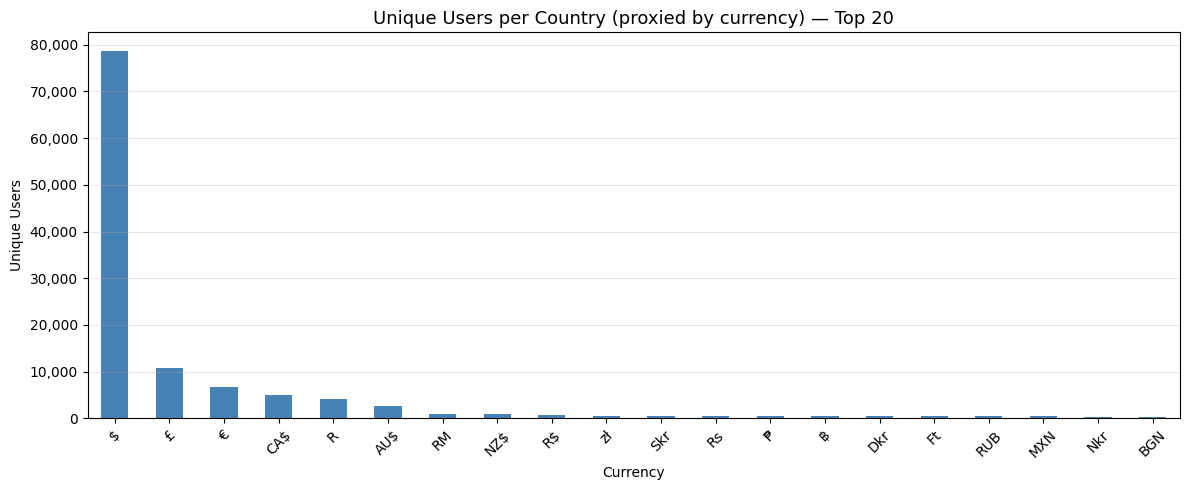

currency
$      78723
£      10847
€       6758
CA$     5073
R       4034
AU$     2594
RM       993
NZ$      992
R$       706
zł       568
Skr      567
Rs       533
₱        480
฿        443
Dkr      428
Ft       415
RUB      396
MXN      388
Nkr      352
BGN      339
Name: user_id, dtype: int64


In [26]:
# Q3.1 — Number of unique users per country (proxied by currency)
users_per_currency = (
    df.groupby('currency')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 5))
users_per_currency.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Unique Users per Country (proxied by currency) — Top 20', fontsize=13)
ax.set_xlabel('Currency')
ax.set_ylabel('Unique Users')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_3_1_users_per_country.png', dpi=150, bbox_inches='tight')
plt.show()

print(users_per_currency)

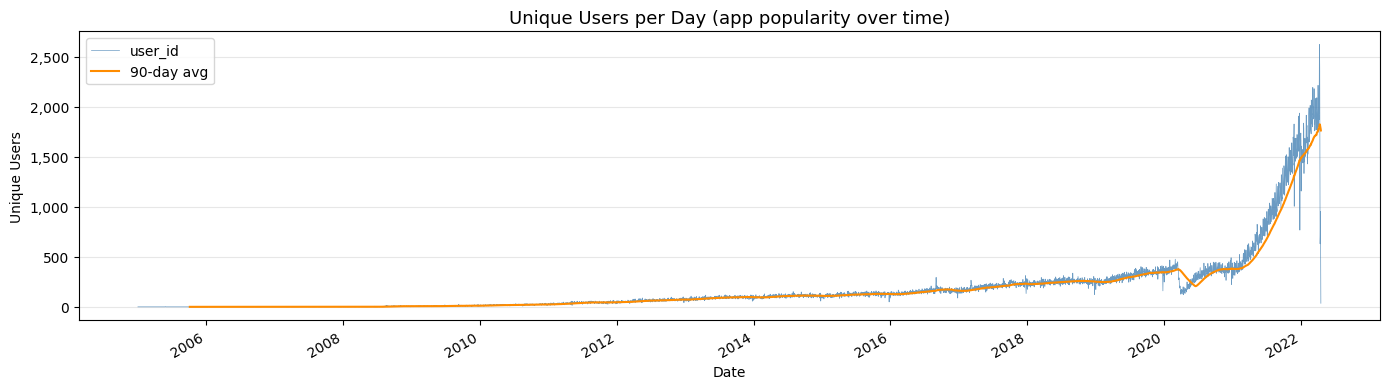

In [27]:
# Q3.2 — Popularity of the app: unique users per day
daily_users = (
    df.groupby('date_fueled')['user_id']
    .nunique()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
daily_users.plot(ax=ax, color='steelblue', linewidth=0.5, alpha=0.8)

# 90-day rolling average to show the trend clearly
daily_users.rolling(90).mean().plot(ax=ax, color='darkorange', linewidth=1.5, label='90-day avg')

ax.set_title('Unique Users per Day (app popularity over time)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Unique Users')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_3_2_users_per_day.png', dpi=150, bbox_inches='tight')
plt.show()

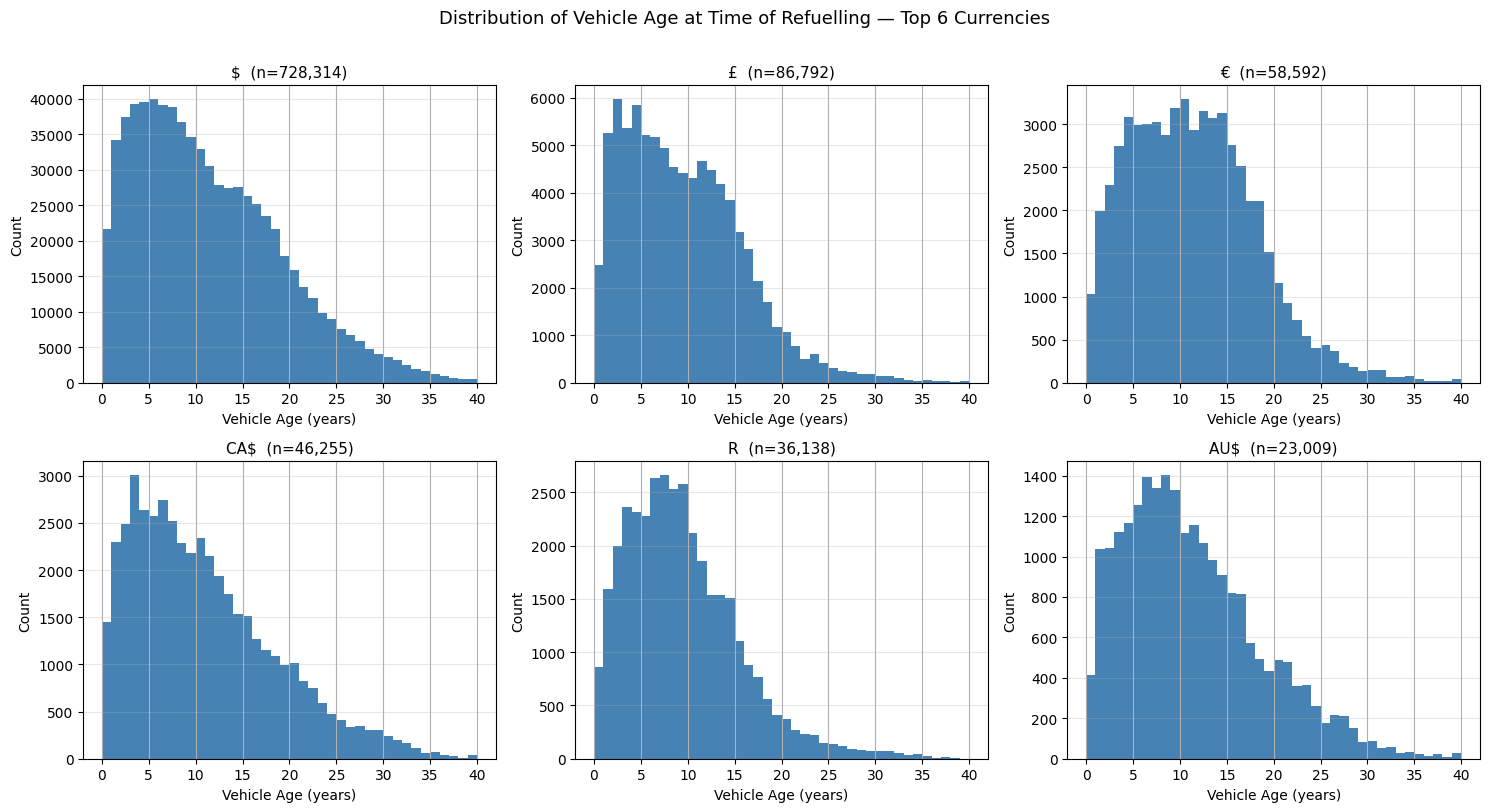

In [28]:
# Q3.3 — Distribution of vehicle age per country (top 6 currencies)
# Vehicle age at time of refuelling = year_fueled - vehicle_year
# We use date_fueled year, NOT today's date

top6_currencies = df['currency'].value_counts().head(6).index.tolist()
df_top6 = df[df['currency'].isin(top6_currencies)].copy()

# Filter year to plausible vehicle manufacture range
df_top6 = df_top6[(df_top6['year'] >= 1980) & (df_top6['year'] <= 2023)]
df_top6['vehicle_age'] = df_top6['date_fueled'].dt.year - df_top6['year']
df_top6 = df_top6[(df_top6['vehicle_age'] >= 0) & (df_top6['vehicle_age'] <= 40)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)

for ax, curr in zip(axes.flat, top6_currencies):
    subset = df_top6[df_top6['currency'] == curr]['vehicle_age']
    subset.hist(bins=40, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(f'{curr}  (n={len(subset):,})', fontsize=11)
    ax.set_xlabel('Vehicle Age (years)')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribution of Vehicle Age at Time of Refuelling — Top 6 Currencies', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_3_3_vehicle_age_per_country.png', dpi=150, bbox_inches='tight')
plt.show()

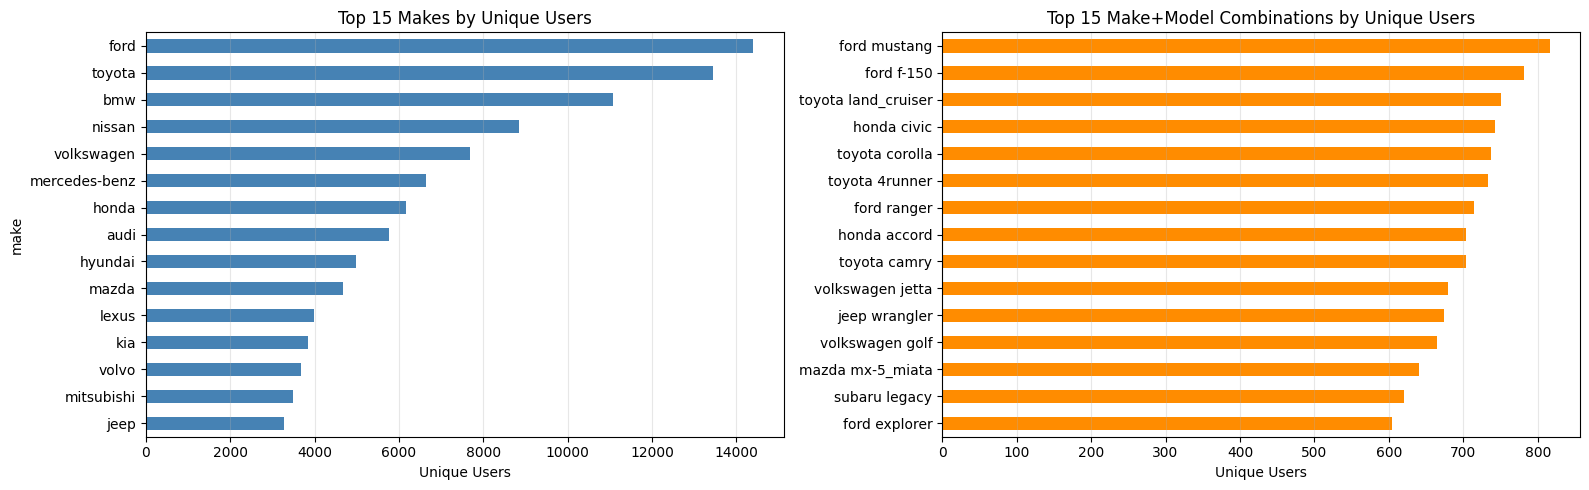

Top 10 makes:
make
ford             14400
toyota           13456
bmw              11065
nissan            8845
volkswagen        7680
mercedes-benz     6647
honda             6164
audi              5762
hyundai           4985
mazda             4666

Top 10 make+model:
ford mustang           816
ford f-150             781
toyota land_cruiser    751
honda civic            743
toyota corolla         737
toyota 4runner         733
ford ranger            715
honda accord           703
toyota camry           703
volkswagen jetta       679


In [29]:
# Q3.4 — Most popular makes and models

# Popularity = number of unique users who have logged at least one entry
make_pop = (
    df.groupby('make')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

model_pop = (
    df.groupby(['make', 'model'])['user_id']
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)
model_pop.index = model_pop.index.map(lambda x: f'{x[0]} {x[1]}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

make_pop.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Top 15 Makes by Unique Users', fontsize=12)
axes[0].set_xlabel('Unique Users')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

model_pop.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='none')
axes[1].set_title('Top 15 Make+Model Combinations by Unique Users', fontsize=12)
axes[1].set_xlabel('Unique Users')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_3_4_popular_makes_models.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 makes:')
print(make_pop.head(10).to_string())
print('\nTop 10 make+model:')
print(model_pop.head(10).to_string())

---
## Section 4 — Fuel Usage
### 4.1 Outlier Removal

In [31]:
# Q4.1.1 — Top 5 currencies by number of transactions
top5_curr = df['currency'].value_counts().head(5)
print('Top 5 currencies by transactions:')
print(top5_curr)

Top 5 currencies by transactions:
currency
$      741876
£       87562
€       59258
CA$     46824
R       36396
Name: count, dtype: int64


In [32]:
# Q4.1.2 — Remove outliers for each of the top 5 currencies separately
#
# Rules applied per currency:
#   gallons        : 1–35 gal
#   litres_per_100km: 3–30
#   cost_per_gallon : currency-specific realistic fuel price window
#   total_spent     : 5th–99th percentile of that currency (removes near-zero
#                     entries and extreme one-off errors)
#
# cost_per_gallon bounds (per US gallon unless noted):
#   $ : $0.50–$15  — US historical range 2005–2022; >$15 flags misattributed SA/other users
#   £ : £3–£12     — UK fuel £1–£2.60/litre × 4.546 L/UK gal
#   € : €2–€12     — European fuel €0.80–€2.50/litre × 3.785 L/gal
#   CA$: CA$0.50–CA$12 — Canadian fuel CA$0.80–CA$2.20/litre × 3.785
#   R  : R20–R200  — SA fuel R6–R26/litre × 3.785 L/gal (2005–2022 range)

cost_bounds = {
    '$':   (0.50,  15.00),
    '£':   (3.00,  12.00),
    '€':   (2.00,  12.00),
    'CA$': (0.50,  12.00),
    'R':   (20.00, 200.00),
}

df_top5 = df[df['currency'].isin(top5_curr.index)].copy()
n_before_top5 = len(df_top5)

keep = pd.Series(False, index=df_top5.index)

for curr, (cpg_lo, cpg_hi) in cost_bounds.items():
    is_curr = df_top5['currency'] == curr
    ts_lo = df_top5.loc[is_curr, 'total_spent_val'].quantile(0.05)
    ts_hi = df_top5.loc[is_curr, 'total_spent_val'].quantile(0.99)

    curr_keep = (
        is_curr &
        df_top5['gallons'].between(1, 35) &
        df_top5['litres_per_100km'].between(3, 30) &
        df_top5['cost_per_gallon_val'].between(cpg_lo, cpg_hi) &
        df_top5['total_spent_val'].between(ts_lo, ts_hi)
    )
    keep = keep | curr_keep

df_clean = df_top5[keep].copy()
print(f'Rows in top-5 currencies before outlier removal: {n_before_top5}')
print(f'Rows after outlier removal                      : {len(df_clean)}')

Rows in top-5 currencies before outlier removal: 971916
Rows after outlier removal                      : 777909


In [33]:
# Q4.1.3 — How many values removed after outlier filtering?
n_removed = n_before_top5 - len(df_clean)
pct_removed = n_removed / n_before_top5 * 100

print(f'Rows removed : {n_removed}  ({pct_removed:.1f}%)')
print(f'Rows kept    : {len(df_clean)}  ({100 - pct_removed:.1f}%)')
print()
print('Per-currency breakdown:')
for curr in top5_curr.index:
    n_orig  = (df_top5['currency'] == curr).sum()
    n_after = (df_clean['currency'] == curr).sum()
    print(f'  {curr}  {n_orig} → {n_after}  (removed {n_orig - n_after})')

Rows removed : 194007  (20.0%)
Rows kept    : 777909  (80.0%)

Per-currency breakdown:
  $  741876 → 591110  (removed 150766)
  £  87562 → 72940  (removed 14622)
  €  59258 → 45471  (removed 13787)
  CA$  46824 → 39884  (removed 6940)
  R  36396 → 28504  (removed 7892)


Cost per litre in ZAR — January 2022:
            mean  median  count
currency                       
€        27.7497 28.4607    977
£        25.7942 25.5449    959
R        18.9146 19.0349    738
CA$      18.0882 17.6293   1567
$        14.7555 13.7295  32552


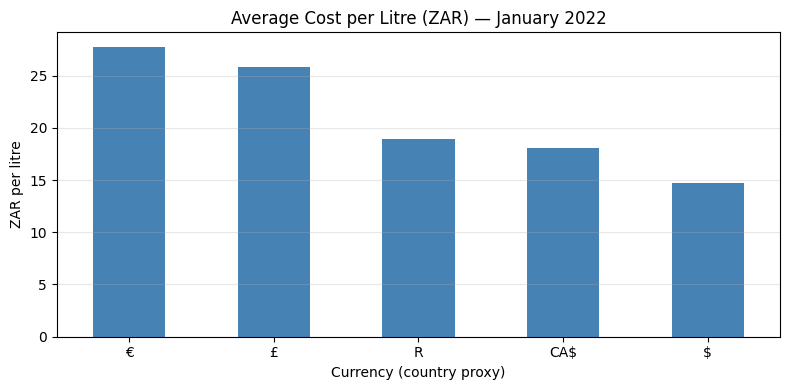

In [34]:
# Q4.2.1 — Cost per litre per country for January 2022, converted to Rands
# Average exchange rates to ZAR for January 2022
# Source: x-rates.com monthly averages — January 2022
#   1 USD = 15.5186 ZAR
#   1 GBP = 21.0379 ZAR
#   1 EUR = 17.5751 ZAR
#   1 CAD = 12.2899 ZAR
#   1 ZAR =  1.00 ZAR

zar_rates = {'$': 15.5186, '£': 21.0379, '€': 17.5751, 'CA$': 12.2899, 'R': 1.00}
litres_per_gal = {'$': 3.78541, '£': 4.54609, '€': 3.78541, 'CA$': 3.78541, 'R': 3.78541}

jan2022 = df_clean[
    (df_clean['date_fueled'].dt.year == 2022) &
    (df_clean['date_fueled'].dt.month == 1)
].copy()

# Cost per litre in local currency, then convert to ZAR
jan2022['cost_per_litre_zar'] = (
    (jan2022['cost_per_gallon_val'] / jan2022['currency'].map(litres_per_gal))
    * jan2022['currency'].map(zar_rates)
)

cpl_jan2022 = (
    jan2022.groupby('currency')['cost_per_litre_zar']
    .agg(mean='mean', median='median', count='count')
    .sort_values('mean', ascending=False)
)
print('Cost per litre in ZAR — January 2022:')
print(cpl_jan2022)

fig, ax = plt.subplots(figsize=(8, 4))
cpl_jan2022['mean'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Average Cost per Litre (ZAR) — January 2022', fontsize=12)
ax.set_xlabel('Currency (country proxy)')
ax.set_ylabel('ZAR per litre')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_4_2_1_cost_per_litre_jan2022.png', dpi=150, bbox_inches='tight')
plt.show()

Threshold : km_driven > 800 km (497 miles)
Flagged as likely missed fill-up: 43378  (5.58% of clean rows)


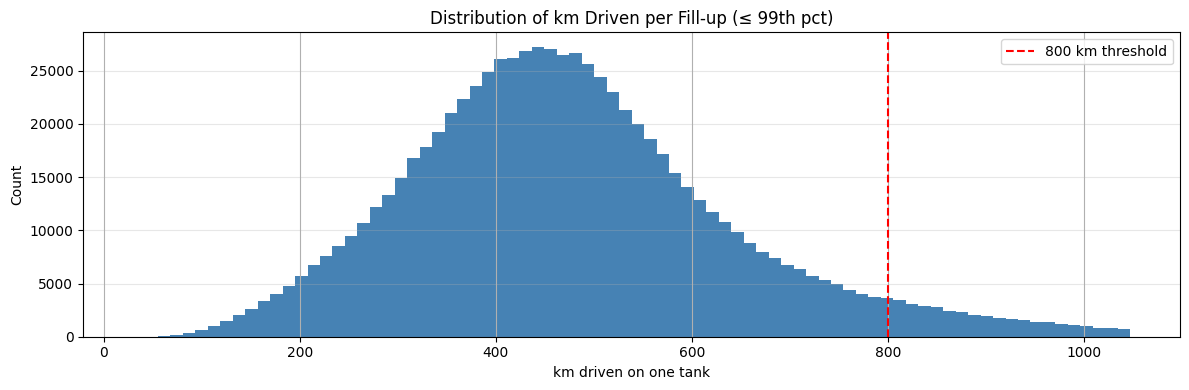

In [35]:
# Q4.2.2 — Identify missed fill-ups from odometer readings
# Basic rule: if km_driven for a single fill-up entry is > 800 km, the user
# most likely missed logging at least one intermediate fill-up.
# (800 km exceeds the realistic single-tank range for ~99% of consumer vehicles:

missed_threshold_km = 800

n_missed = (df_clean['km_driven'] > missed_threshold_km).sum()
pct_missed = n_missed / len(df_clean) * 100

print(f'Threshold : km_driven > {missed_threshold_km} km ({missed_threshold_km/1.60934:.0f} miles)')
print(f'Flagged as likely missed fill-up: {n_missed}  ({pct_missed:.2f}% of clean rows)')

# Distribution of km_driven to contextualise the threshold
fig, ax = plt.subplots(figsize=(12, 4))
cap = df_clean['km_driven'].quantile(0.99)
df_clean.loc[df_clean['km_driven'] <= cap, 'km_driven'].hist(bins=80, ax=ax, color='steelblue', edgecolor='none')
ax.axvline(missed_threshold_km, color='red', linewidth=1.5, linestyle='--', label=f'{missed_threshold_km} km threshold')
ax.set_title('Distribution of km Driven per Fill-up (≤ 99th pct)', fontsize=12)
ax.set_xlabel('km driven on one tank')
ax.set_ylabel('Count')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_4_2_2_missed_fillup.png', dpi=150, bbox_inches='tight')
plt.show()

Average km driven per fill-up:
currency
€     592.8662
£     582.5866
R     533.9647
$     463.0983
CA$   444.1131


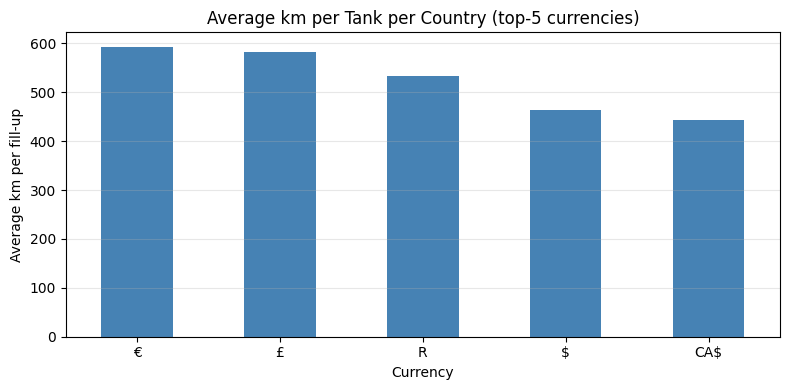

In [37]:
# Q4.2.3 — Average km per tank per country (top 5 currencies)
avg_km_country = (
    df_clean.groupby('currency')['km_driven']
    .mean()
    .sort_values(ascending=False)
)

print('Average km driven per fill-up:')
print(avg_km_country.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
avg_km_country.plot(kind = 'bar', ax = ax, color = 'steelblue', edgecolor = 'none')
ax.set_title('Average km per Tank per Country (top-5 currencies)', fontsize=12)
ax.set_xlabel('Currency')
ax.set_ylabel('Average km per fill-up')
ax.tick_params(axis = 'x', rotation=0)
ax.grid(axis = 'y', alpha = 0.3)
plt.tight_layout()
plt.savefig('fig_4_2_3_avg_km_per_country.png', dpi = 150, bbox_inches = 'tight')
plt.show()

Countries using the european and british countries show higher average distance per tank than South Africa, US, and Canada. This may be partly due to the differences in vehicle types, fuel prices, driving patterns, and fuel-efficiency regulations across these countries. European countries tend to have a greater proportion of smaller, fuel-efficient vehicles, partly due to higher fuel costs and strict emissions standards. In contrast, the US and Canada have a historic tendency to adopt larger SUVs and pickup trucks, which generally consume more fuel and therefore travel fewer kilometres per tank.

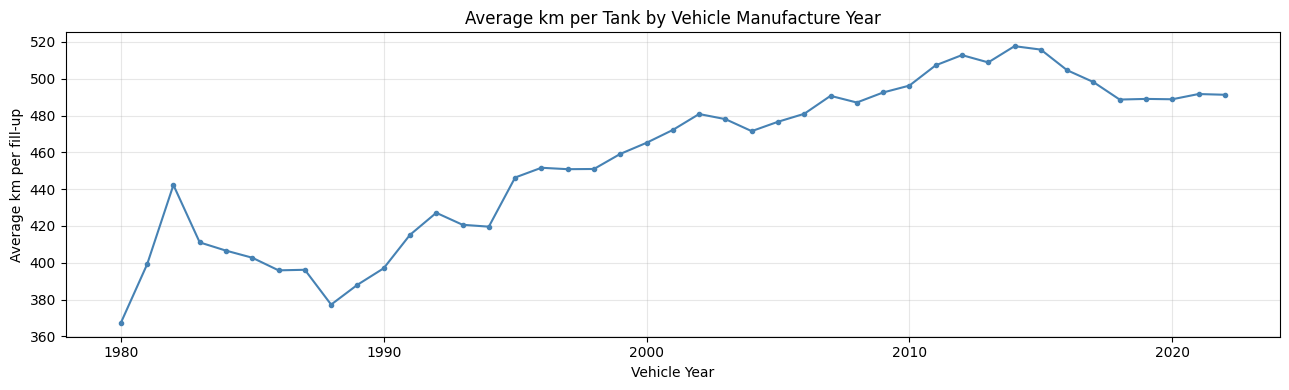

         mean  count
year                
2013 508.8426  39003
2014 517.6635  39577
2015 515.8001  41002
2016 504.6084  37920
2017 498.1794  34602
2018 488.6653  31912
2019 489.0115  27292
2020 488.8194  21150
2021 491.6616  18191
2022 491.2655   2776


In [38]:
# Q4.2.4 — Do newer vehicles drive further per tank?
# Group by vehicle manufacture year; require at least 50 entries per year for stability

df_valid_year = df_clean[(df_clean['year'] >= 1980) & (df_clean['year'] <= 2022)].copy()

year_km = (
    df_valid_year.groupby('year')['km_driven']
    .agg(mean='mean', count='count')
    .query('count >= 50')
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(year_km.index, year_km['mean'], color='steelblue', linewidth=1.5, marker='o', markersize=3)
ax.set_title('Average km per Tank by Vehicle Manufacture Year', fontsize=12)
ax.set_xlabel('Vehicle Year')
ax.set_ylabel('Average km per fill-up')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_4_2_4_km_by_vehicle_year.png', dpi=150, bbox_inches='tight')
plt.show()

print(year_km.tail(10).to_string())

Yes, newer vehicles generally drive farther between fill-ups. The plot shows an overall upward trend in average kilometres per fill-up, increasing from approximately 370 km for vehicles manufactured around 1980 to around 490 - 520 km for vehicles manufactured after 2010. This suggests that newer vehicles tend to have greater driving range between refuelling stops.

Top 5 SA vehicles — fuel efficiency (L/100km):
                     mean  median  count
make_model                              
toyota hilux      12.0965 11.3084   1112
mitsubishi pajero 12.8303 12.1700    930
toyota fortuner   11.3365 10.9402    896
suzuki jimny       9.2054  8.9097    781
volkswagen polo    7.7443  7.3276    634


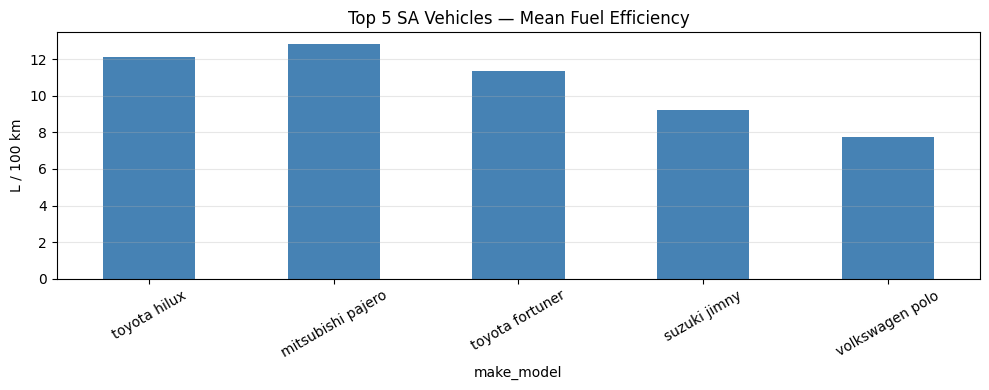

In [39]:
# Q4.2.5 — Top 5 SA vehicles and their fuel efficiency
df_sa = df_clean[df_clean['currency'] == 'R'].copy()
df_sa['make_model'] = df_sa['make'] + ' ' + df_sa['model']

top5_sa_vehicles = (
    df_sa.groupby('make_model')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

sa_efficiency = (
    df_sa[df_sa['make_model'].isin(top5_sa_vehicles)]
    .groupby('make_model')['litres_per_100km']
    .agg(mean='mean', median='median', count='count')
    .loc[top5_sa_vehicles]   # preserve popularity order
)

print('Top 5 SA vehicles — fuel efficiency (L/100km):')
print(sa_efficiency.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
sa_efficiency['mean'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Top 5 SA Vehicles — Mean Fuel Efficiency', fontsize=12)
ax.set_ylabel('L / 100 km')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_4_2_5_sa_top5_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

The calculated fuel-efficiency values appear broadly realistic, particularly for the larger SUVs and pickup vehicles, although they are generally higher than manufacturer-reported combined-cycle figures. The Mitsubishi Pajero, Toyota Hilux and Toyota Fortuner have relatively high fuel consumption, which is expected given their larger size, weight and SUV/pickup design. The Suzuki Jimny has a surprisingly high consumption for a small vehicle, but its boxy design and four-wheel-drive system can reduce efficiency. The Volkswagen Polo has the lowest consumption of the five vehicles, although its average of approximately 7.7 L/100 km is higher than the approximately 5 - 6.5 L/100 km figures reported for several South African Polo variants. This difference may be showing that the dataset reflects more realistic driving conditions rather than controlled manufacturer testing.

In [40]:
# Q4.2.6 — Most fuel-efficient vehicle per country
# Require >= 30 entries per make+model per currency for statistical reliability
df_clean['make_model'] = df_clean['make'] + ' ' + df_clean['model']

min_entries = 30

best_per_country = {}
for curr in top5_curr.index:
    sub = df_clean[df_clean['currency'] == curr]
    grp = (
        sub.groupby('make_model')['litres_per_100km']
        .agg(mean='mean', count='count')
        .query(f'count >= {min_entries}')
        .sort_values('mean')
    )
    best_per_country[curr] = grp.head(5)

for curr, tbl in best_per_country.items():
    print(f'\n=== {curr} — Top 5 most fuel-efficient vehicles ===')
    print(tbl.to_string())


=== $ — Top 5 most fuel-efficient vehicles ===
                       mean  count
make_model                        
toyota prius_prime   4.1947    374
toyota prius_plug-in 4.7158    600
honda clarity        4.8190    138
toyota prius_limited 4.9308     33
hyundai ioniq        4.9557    588

=== £ — Top 5 most fuel-efficient vehicles ===
                      mean  count
make_model                       
hyundai ioniq       5.3803    110
bmw 116ed           5.9213     33
toyota prius        6.0412     35
kia niro            6.0524     67
mercedes-benz a180d 6.0571     42

=== € — Top 5 most fuel-efficient vehicles ===
                              mean  count
make_model                               
hyundai ioniq               4.8358     50
toyota auris_touring_sports 4.9755     78
toyota prius                5.1496     46
volvo v40_cross_country     5.2842     32
kia niro                    5.4151     58

=== CA$ — Top 5 most fuel-efficient vehicles ===
                           me

Canadian top-5 vehicles — mean L/100km by season:
season            Winter  Spring  Summer   Fall
make_model                                     
hyundai accent    9.1223  8.2609  7.8765 8.0625
mazda 3_sport     8.4873  8.3238  7.8258 7.9740
toyota matrix     9.3043  9.2440  8.6361 8.6829
volkswagen golf   7.7293  7.5011  7.2017 7.1422
volkswagen jetta  7.5027  7.0506  6.7670 7.3661


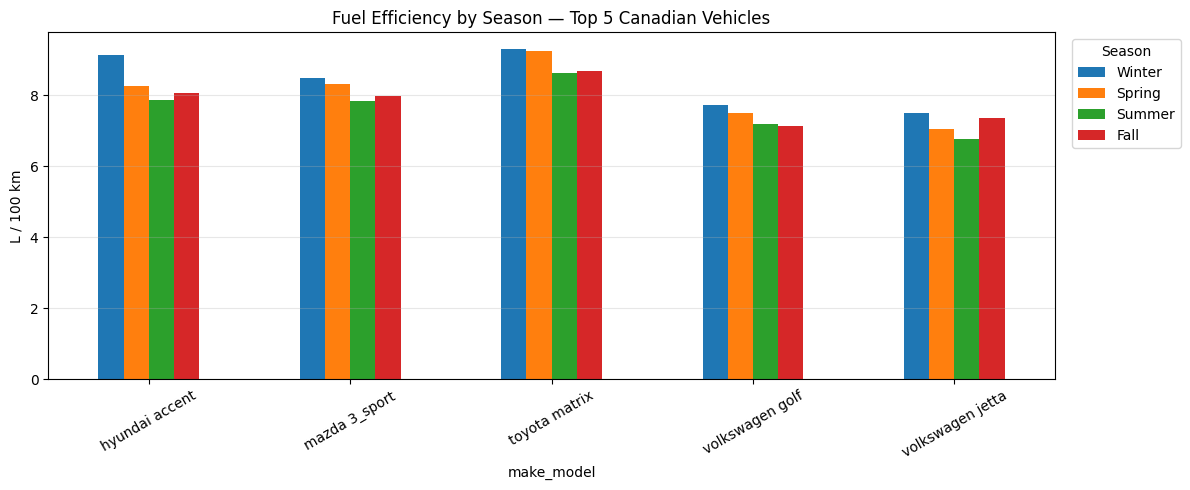

In [ ]:
# Q4.2.7 — Fuel efficiency by season for top 5 Canadian vehicles
df_ca = df_clean[df_clean['currency'] == 'CA$'].copy()
df_ca['make_model'] = df_ca['make'] + ' ' + df_ca['model']

top5_ca_vehicles = (
    df_ca.groupby('make_model')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

# Canadian meteorological seasons
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
               3: 'Spring',  4: 'Spring',  5: 'Spring',
               6: 'Summer',  7: 'Summer',  8: 'Summer',
               9: 'Fall',   10: 'Fall',   11: 'Fall'}

df_ca['season'] = df_ca['date_fueled'].dt.month.map(season_map)

df_ca_top5 = df_ca[df_ca['make_model'].isin(top5_ca_vehicles)]

seasonal_eff = (
    df_ca_top5.groupby(['make_model', 'season'])['litres_per_100km']
    .mean()
    .unstack('season')
    [['Winter', 'Spring', 'Summer', 'Fall']]   # fixed season order
)

print('Canadian top-5 vehicles — mean L/100km by season:')
print(seasonal_eff.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
seasonal_eff.plot(kind='bar', ax=ax, edgecolor='none')
ax.set_title('Fuel Efficiency by Season — Top 5 Canadian Vehicles', fontsize=12)
ax.set_ylabel('L / 100 km')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Season', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_4_2_7_canada_seasonal_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

yes, there is a noticeable seasonal effect, but it isn't huge for most of these vehicles. The Hyundai Accent stands out as having the largest seasonal variation, while the other four vehicles are fairly consistent.

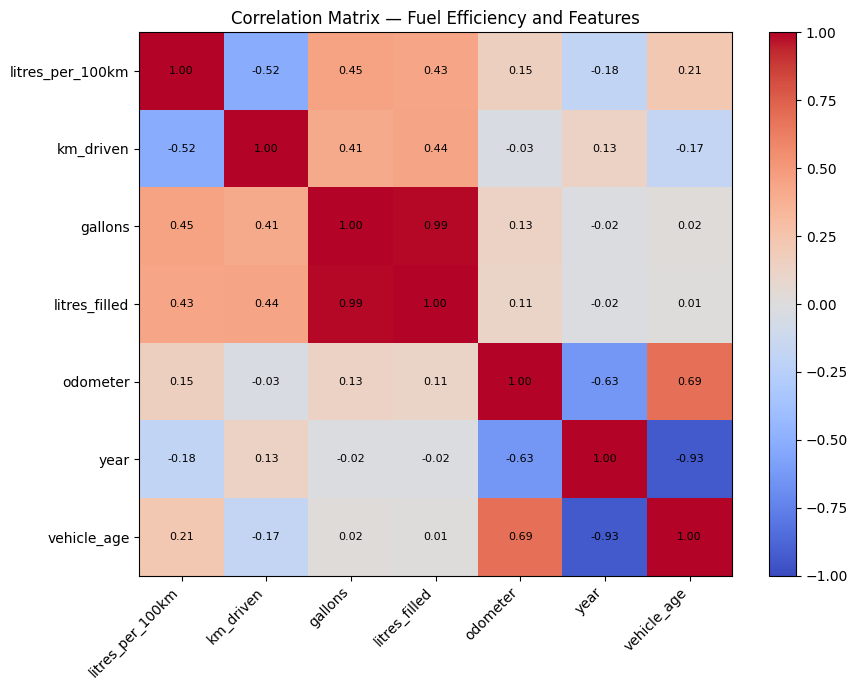

Correlations with litres_per_100km:
km_driven       -0.5182
year            -0.1817
odometer         0.1493
vehicle_age      0.2142
litres_filled    0.4328
gallons          0.4518
Name: litres_per_100km, dtype: float64


In [41]:
# Q4.2.8 — Correlations between fuel efficiency and other features

df_valid_year = df_clean[(df_clean['year'] >= 1980) & (df_clean['year'] <= 2022)].copy()
df_valid_year['vehicle_age'] = df_valid_year['date_fueled'].dt.year - df_valid_year['year']

corr_cols = ['litres_per_100km', 'km_driven', 'gallons', 'litres_filled',
             'odometer', 'year', 'vehicle_age']
corr_matrix = df_valid_year[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Correlation Matrix — Fuel Efficiency and Features', fontsize=12)
plt.tight_layout()
plt.savefig('fig_4_2_8_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlations with litres_per_100km:')
print(corr_matrix['litres_per_100km'].drop('litres_per_100km').sort_values())

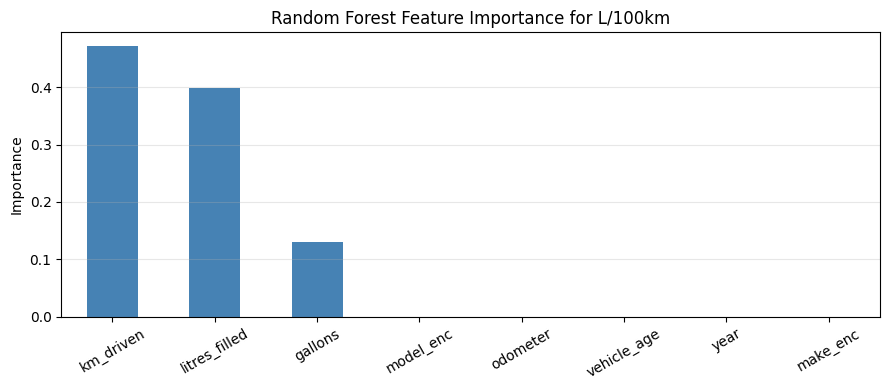

Feature importances:
km_driven       0.4718
litres_filled   0.3980
gallons         0.1301
model_enc       0.0000
odometer        0.0000
vehicle_age     0.0000
year            0.0000
make_enc        0.0000


In [42]:
# Q4.2.9 — Random Forest feature importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

rf_data = df_valid_year[['litres_per_100km', 'km_driven', 'gallons',
                          'litres_filled', 'odometer', 'year',
                          'vehicle_age', 'make', 'model']].dropna().copy()

# Encode make and model as integer codes (no def/class needed)
rf_data['make_enc']  = LabelEncoder().fit_transform(rf_data['make'].astype(str))
rf_data['model_enc'] = LabelEncoder().fit_transform(rf_data['model'].astype(str))

feature_cols = ['km_driven', 'gallons', 'litres_filled', 'odometer',
                'year', 'vehicle_age', 'make_enc', 'model_enc']
X = rf_data[feature_cols]
y = rf_data['litres_per_100km']

# Train on a 200k-row sample for speed; results are representative at this size
sample_idx = X.sample(min(200_000, len(X)), random_state=42).index
rf = RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
rf.fit(X.loc[sample_idx], y.loc[sample_idx])

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
importances.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Random Forest Feature Importance for L/100km', fontsize=12)
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_4_2_9_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature importances:')
print(importances.to_string())

In [43]:
# Q4.3.1 — Filter to SA drivers (currency = R)
df_sa_full = df_clean[df_clean['currency'] == 'R'].copy()
df_sa_full['cost_per_litre_r'] = df_sa_full['cost_per_gallon_val'] / 3.78541

print(f'SA rows: {len(df_sa_full):,}')
print(f'Date range: {df_sa_full["date_fueled"].min().date()} – {df_sa_full["date_fueled"].max().date()}')

SA rows: 28,504
Date range: 2005-09-10 – 2022-04-16


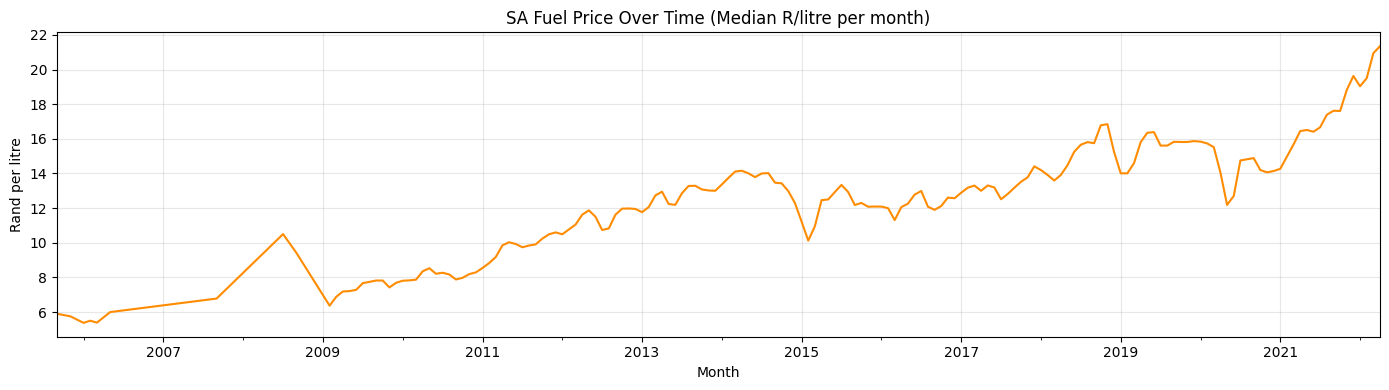

In [46]:
# Q4.3.2 — Plot SA fuel prices over time (monthly median R/litre)
monthly_price = (
    df_sa_full.groupby(df_sa_full['date_fueled'].dt.to_period('M'))['cost_per_litre_r']
    .median()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
monthly_price.plot(ax=ax, color='darkorange', linewidth=1.5)
ax.set_title('SA Fuel Price Over Time (Median R/litre per month)', fontsize=12)
ax.set_xlabel('Month')
ax.set_ylabel('Rand per litre')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_4_3_2_sa_fuel_price.png', dpi=150, bbox_inches='tight')
plt.show()

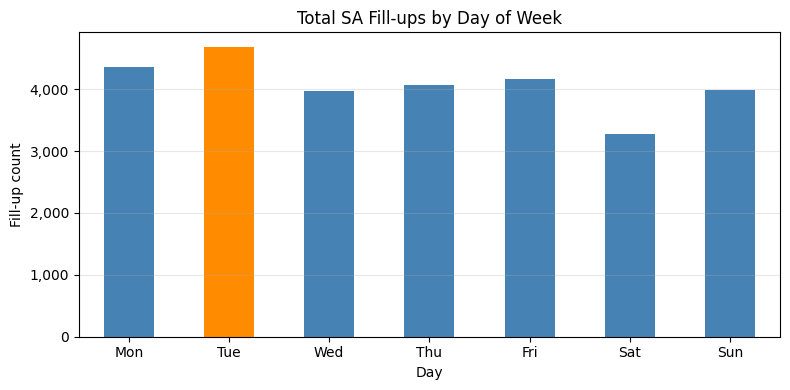

day_of_week
Mon    4361
Tue    4685
Wed    3968
Thu    4064
Fri    4172
Sat    3273
Sun    3981
dtype: int64


In [47]:
# Q4.3.3 — Do more people refuel on a Tuesday vs other days?
# day_of_week: Monday=0, Tuesday=1, ... Sunday=6
df_sa_full['day_of_week'] = df_sa_full['date_fueled'].dt.dayofweek
day_names = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

fills_per_day = df_sa_full.groupby('day_of_week').size().rename(day_names)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['darkorange' if d == 'Tue' else 'steelblue' for d in fills_per_day.index]
fills_per_day.plot(kind='bar', ax=ax, color=colors, edgecolor='none')
ax.set_title('Total SA Fill-ups by Day of Week', fontsize=12)
ax.set_xlabel('Day')
ax.set_ylabel('Fill-up count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_4_3_3_sa_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()

print(fills_per_day)

In [49]:
# Q4.3.4 — Extract only entries on the 1st Tuesday and 1st Wednesday of each month
# For each (year, month), find the first Tuesday (dayofweek=1) and first Wednesday (2)

df_sa_full['year_month'] = df_sa_full['date_fueled'].dt.to_period('M')

# For each month, find the date of the first Tuesday and first Wednesday
first_tue_wed = {}
for ym in df_sa_full['year_month'].unique():
    month_start = ym.to_timestamp()
    for delta in range(7):
        d = month_start + pd.Timedelta(days=delta)
        if d.dayofweek == 1 and 'tue' not in first_tue_wed.get(str(ym), {}):
            first_tue_wed.setdefault(str(ym), {})['tue'] = d.normalize()
        if d.dayofweek == 2 and 'wed' not in first_tue_wed.get(str(ym), {}):
            first_tue_wed.setdefault(str(ym), {})['wed'] = d.normalize()

first_tues = pd.Series({k: v['tue'] for k, v in first_tue_wed.items() if 'tue' in v})
first_weds  = pd.Series({k: v['wed'] for k, v in first_tue_wed.items() if 'wed' in v})

valid_dates = set(first_tues.values) | set(first_weds.values)
df_tuewed = df_sa_full[df_sa_full['date_fueled'].isin(valid_dates)].copy()
df_tuewed['is_tuesday'] = df_tuewed['date_fueled'].dt.dayofweek == 1

print(f'Entries on 1st Tue or 1st Wed of each month: {len(df_tuewed)}')
print(f'  Tuesdays : {df_tuewed["is_tuesday"].sum()}')
print(f'  Wednesdays: {(~df_tuewed["is_tuesday"]).sum()}')

Entries on 1st Tue or 1st Wed of each month: 2363
  Tuesdays : 1494
  Wednesdays: 869


In [50]:
# Q4.3.5 — Indicator: did the price go up or down that month?
# Proxy: compare the median fuel price on the 1st Wednesday (post-adjustment)
# to the 1st Tuesday (pre-adjustment midnight). If Wednesday median > Tuesday median → price up.

monthly_direction = {}
for ym_str, dates in first_tue_wed.items():
    if 'tue' not in dates or 'wed' not in dates:
        continue
    tue_prices = df_sa_full.loc[df_sa_full['date_fueled'] == dates['tue'], 'cost_per_litre_r']
    wed_prices = df_sa_full.loc[df_sa_full['date_fueled'] == dates['wed'], 'cost_per_litre_r']
    if tue_prices.empty or wed_prices.empty:
        continue
    # Price went up if Wednesday's median is higher than Tuesday's median
    monthly_direction[ym_str] = 'up' if wed_prices.median() > tue_prices.median() else 'down'

direction_series = pd.Series(monthly_direction, name='price_direction')
print('Price direction counts:')
print(direction_series.value_counts())

# Map direction back to df_tuewed
df_tuewed['year_month_str'] = df_tuewed['year_month'].astype(str)
df_tuewed['price_direction'] = df_tuewed['year_month_str'].map(direction_series)
df_tuewed = df_tuewed[df_tuewed['price_direction'].notna()].copy()

print(f'\nRows with direction label: {len(df_tuewed):,}')

Price direction counts:
price_direction
up      71
down    53
Name: count, dtype: int64

Rows with direction label: 2,329


1st Wednesday fill-up counts by price direction:
price_direction
down    414
up      442
dtype: int64

Average fill-ups per 1st Wednesday:
price_direction
down   7.8113
up     6.2254
dtype: float64


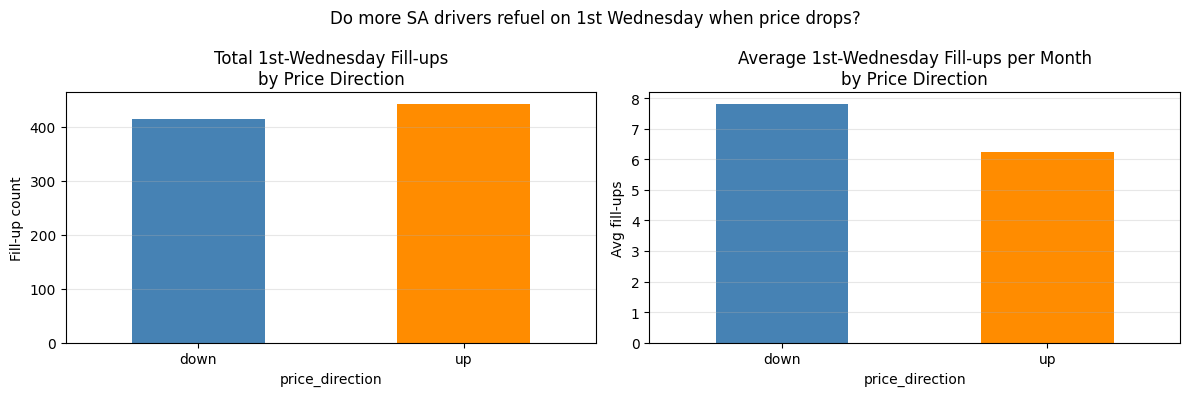

In [51]:
# Q4.3.6 — Do more people refuel on 1st Wednesday when price goes DOWN?
# Compare the count of fill-ups on 1st Wednesdays in down-price months vs up-price months

wed_fills = df_tuewed[~df_tuewed['is_tuesday']].groupby('price_direction').size()
print('1st Wednesday fill-up counts by price direction:')
print(wed_fills)

# Normalise by number of months in each direction group
n_months_per_direction = direction_series.value_counts()
wed_avg = wed_fills / n_months_per_direction
print('\nAverage fill-ups per 1st Wednesday:')
print(wed_avg)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
wed_fills.plot(kind='bar', ax=axes[0], color=['steelblue','darkorange'], edgecolor='none')
axes[0].set_title('Total 1st-Wednesday Fill-ups\nby Price Direction')
axes[0].set_ylabel('Fill-up count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

wed_avg.plot(kind='bar', ax=axes[1], color=['steelblue','darkorange'], edgecolor='none')
axes[1].set_title('Average 1st-Wednesday Fill-ups per Month\nby Price Direction')
axes[1].set_ylabel('Avg fill-ups')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Do more SA drivers refuel on 1st Wednesday when price drops?', fontsize=12)
plt.tight_layout()
plt.savefig('fig_4_3_6_wednesday_price_down.png', dpi=150, bbox_inches='tight')
plt.show()

1st Tuesday fill-up counts by price direction:
price_direction
down     378
up      1095
dtype: int64

Average fill-ups per 1st Tuesday:
price_direction
down    7.1321
up     15.4225
dtype: float64


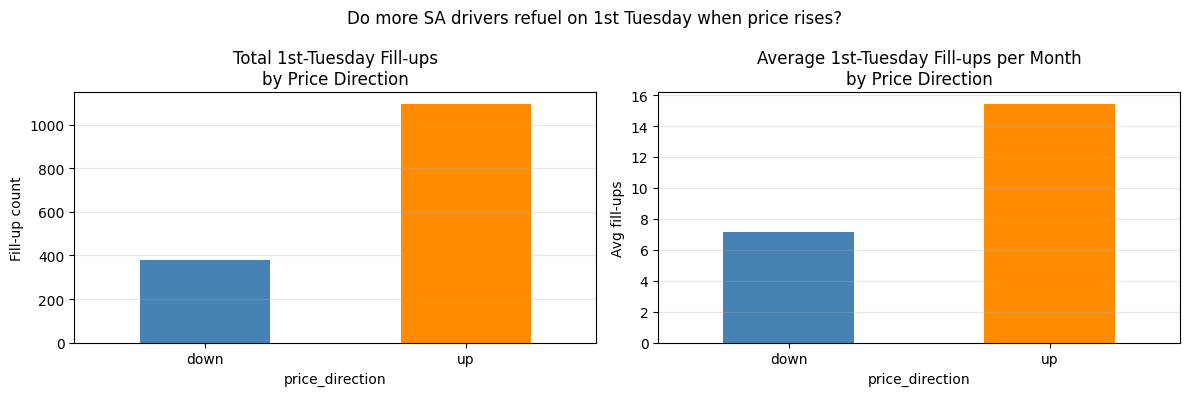

In [52]:
# Q4.3.7 — Do more people refuel on 1st Tuesday when price goes UP?
tue_fills = df_tuewed[df_tuewed['is_tuesday']].groupby('price_direction').size()
print('1st Tuesday fill-up counts by price direction:')
print(tue_fills)

tue_avg = tue_fills / n_months_per_direction
print('\nAverage fill-ups per 1st Tuesday:')
print(tue_avg)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tue_fills.plot(kind='bar', ax=axes[0], color=['steelblue','darkorange'], edgecolor='none')
axes[0].set_title('Total 1st-Tuesday Fill-ups\nby Price Direction')
axes[0].set_ylabel('Fill-up count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

tue_avg.plot(kind='bar', ax=axes[1], color=['steelblue','darkorange'], edgecolor='none')
axes[1].set_title('Average 1st-Tuesday Fill-ups per Month\nby Price Direction')
axes[1].set_ylabel('Avg fill-ups')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Do more SA drivers refuel on 1st Tuesday when price rises?', fontsize=12)
plt.tight_layout()
plt.savefig('fig_4_3_7_tuesday_price_up.png', dpi=150, bbox_inches='tight')
plt.show()